# 04번 백테스트 결과 확인 + KOSPI 워커 2대 vs 4대 비교

`check_04_backtest.ipynb`의 전체 확인 항목(성과 랭킹, monthly/quarterly 비교, 특정 전략
시계열, held_count 추이, 이상치 확인)을 이번 KOSPI 전용 벤치마크 결과(`backtest_results_kospi_2w`)
에 대해 그대로 수행하고, 이어서 워커 4대(튜닝) 결과(`backtest_results_kospi_4w_tuned`)와
직접 대조한다.

- `data/backtest_results_kospi_2w` — 워커 2대(4코어), shuffle.partitions=4 (기본), --years 2021,2022,2023, --market KOSPI
- `data/backtest_results_kospi_4w_tuned` — 워커 4대(8코어), shuffle.partitions=8 (튜닝), 동일 조건

**소요시간 비교는 이 노트북이 아니라 Spark 마스터 UI(`http://localhost:8088`)의
Completed Applications 표 `Duration` 컬럼에서 확인한다** (Spark가 모든 애플리케이션의
소요시간을 자동 기록하므로 별도 측정 불필요). 이 노트북은 두 실행의 *결과 내용이
실제로 동일한지*(튜닝이 계산 결과를 바꾸지 않았는지)를 검증하는 용도다.

**주의**: 이 노트북을 Jupyter에서 열어둔 상태로 파일이 외부에서 다시 갱신되면, 저장
시점에 브라우저가 들고 있던 옛 버전으로 덮어써질 수 있다. 새로 열 때는 브라우저 탭을
완전히 닫았다가 다시 열어(재로드) 최신 파일 내용을 확실히 불러온 뒤 실행할 것.

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("spark://spark-master:7077").appName("check_04_01").getOrCreate()

summary = spark.read.parquet("/opt/spark-apps/data/backtest_results_kospi_2w/summary")
period = spark.read.parquet("/opt/spark-apps/data/backtest_results_kospi_2w/period_returns")

print(f"전략 수(summary): {summary.count()}")
print(f"구간 수익률 행 수(period_returns): {period.count()}")
summary.printSchema()

전략 수(summary): 1000
구간 수익률 행 수(period_returns): 23000
root
 |-- name: string (nullable = true)
 |-- final_cum_return: double (nullable = true)
 |-- mdd: double (nullable = true)
 |-- avg_period_return: double (nullable = true)
 |-- stddev_period_return: double (nullable = true)
 |-- sharpe_ratio: double (nullable = true)



## 1. 누적수익률 상위 20개 전략

In [13]:
top20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.desc("final_cum_return")).limit(20).toPandas()
top20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per10_pbr0.8_dynone_monthly_n20,0.725571,-0.512873,0.028732,0.190045,0.151184
1,per8_pbr0.8_dynone_monthly_n20,0.725571,-0.512873,0.028732,0.190045,0.151184
2,per10_pbr0.8_dynone_monthly_n10,0.643868,-0.665251,0.043578,0.331452,0.131475
3,per8_pbr0.8_dynone_monthly_n10,0.643868,-0.665251,0.043578,0.331452,0.131475
4,per10_pbr0.8_dynone_monthly_n30,0.516745,-0.474062,0.021044,0.151590,0.138825
5,per8_pbr0.8_dynone_monthly_n30,0.516745,-0.474062,0.021044,0.151590,0.138825
6,per12_pbr0.8_dynone_monthly_n20,0.448313,-0.512873,0.021561,0.173336,0.124391
7,per15_pbr0.8_dynone_monthly_n20,0.448313,-0.512873,0.021561,0.173336,0.124391
8,per20_pbr0.8_dynone_monthly_n20,0.448313,-0.512873,0.021561,0.173336,0.124391
9,per10_pbr1.0_dynone_monthly_n20,0.435661,-0.512873,0.021118,0.171901,0.122853


## 2. 누적수익률 하위 20개 전략

In [14]:
bottom20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.asc("final_cum_return")).limit(20).toPandas()
bottom20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per10_pbr2.0_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
1,per10_pbr0.8_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
2,per10_pbr1.2_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
3,per10_pbr1.5_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
4,per12_pbr1.5_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
5,per10_pbr1.0_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
6,per12_pbr0.8_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
7,per12_pbr1.0_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
8,per12_pbr1.2_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897
9,per20_pbr1.5_dy3.0_quarterly_n10,-0.520556,-0.545956,-0.057516,0.121367,-0.473897


## 3. 샤프비율 상위 20개 전략 (수익률 대비 위험조정 성과)

In [15]:
top_sharpe = summary.filter(F.col("sharpe_ratio").isNotNull()) \
    .orderBy(F.desc("sharpe_ratio")).limit(20).toPandas()
top_sharpe

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per10_pbr1.2_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
1,per10_pbr1.5_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
2,per10_pbr2.0_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
3,per12_pbr1.2_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
4,per12_pbr1.5_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
5,per12_pbr2.0_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
6,per15_pbr1.2_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
7,per15_pbr1.5_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
8,per15_pbr2.0_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854
9,per20_pbr1.2_dynone_quarterly_n10,0.094867,-0.644140,0.092999,0.592900,0.156854


## 4. monthly vs quarterly 리밸런싱 주기 비교
전략 이름에서 rebalance 종류를 뽑아 그룹별 평균 성과를 비교한다.
(이름 규칙: `per{PER상한}_pbr{PBR상한}_dy{배당하한}_{rebalance}_n{보유종목수}`)

In [16]:
with_rebalance = summary.withColumn(
    "rebalance",
    F.when(F.col("name").contains("_monthly_"), "monthly").otherwise("quarterly"),
)

with_rebalance.groupBy("rebalance").agg(
    F.avg("final_cum_return").alias("avg_final_cum_return"),
    F.avg("mdd").alias("avg_mdd"),
    F.avg("sharpe_ratio").alias("avg_sharpe_ratio"),
    F.count("*").alias("strategy_count"),
).toPandas()

,rebalance,avg_final_cum_return,avg_mdd,avg_sharpe_ratio,strategy_count
0,monthly,0.003211,-0.465449,0.03412,500
1,quarterly,-0.272623,-0.440515,-0.23225,500


## 5. 특정 전략 하나의 구간별 수익률 시계열
이름을 바꿔서 원하는 전략의 리밸런싱 구간별 수익률 흐름을 확인할 수 있다.

In [17]:
target_strategy = "per8_pbr1.2_dynone_monthly_n10"

one_strategy = period.filter(F.col("name") == target_strategy) \
    .orderBy("period_start").toPandas()
one_strategy

,name,period_return,held_count,period_start,period_end
0,per8_pbr1.2_dynone_monthly_n10,0.015804,2,20210131,20210228
1,per8_pbr1.2_dynone_monthly_n10,0.280965,2,20210228,20210331
2,per8_pbr1.2_dynone_monthly_n10,0.030523,10,20210331,20210430
3,per8_pbr1.2_dynone_monthly_n10,-0.011044,10,20210430,20210531
4,per8_pbr1.2_dynone_monthly_n10,0.050655,10,20210531,20210630
5,per8_pbr1.2_dynone_monthly_n10,-0.032308,10,20210630,20210731
6,per8_pbr1.2_dynone_monthly_n10,-0.077016,10,20210731,20210831
7,per8_pbr1.2_dynone_monthly_n10,-0.051305,10,20210831,20210930
8,per8_pbr1.2_dynone_monthly_n10,-0.032925,10,20210930,20211031
9,per8_pbr1.2_dynone_monthly_n10,-0.157220,10,20211031,20211130


### 누적수익률 곡선 그래프

/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_32205/2427691822.py:10: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-package

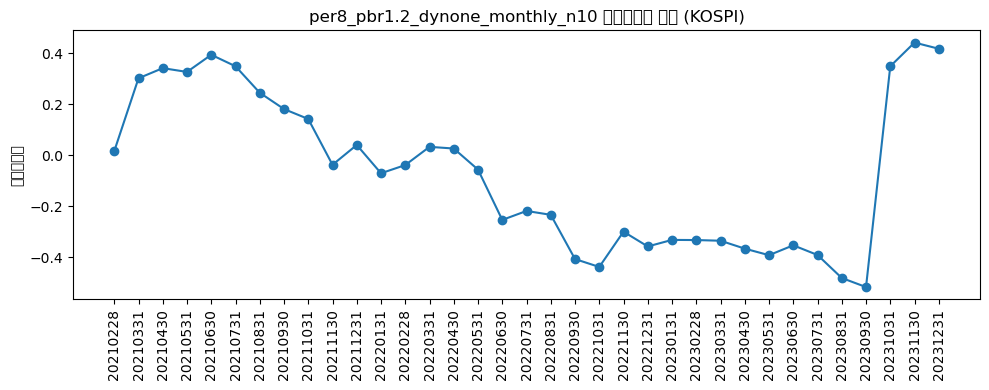

In [18]:
import matplotlib.pyplot as plt

one_strategy["cum_return"] = (1 + one_strategy["period_return"]).cumprod() - 1

plt.figure(figsize=(10, 4))
plt.plot(one_strategy["period_end"], one_strategy["cum_return"], marker="o")
plt.xticks(rotation=90)
plt.title(f"{target_strategy} 누적수익률 추이 (KOSPI)")
plt.ylabel("누적수익률")
plt.tight_layout()
plt.show()

## 6. 종목 보유 수(held_count) 추이 - FY2020 데이터 보강 효과 확인
시점이 갈수록 그 시점 이전에 공시된 사업보고서가 누적되므로, 초반 시점(2021년 초)은 held_count가
적고 뒤로 갈수록 늘어나는 것이 정상이다. 특히 2021년 3월(FY2020 사업보고서 정기공시 시즌) 전후로
표본이 급증하는지 - 룩어헤드 바이어스 방지 로직과 FY2020 데이터 보강 효과가 같이 작동하는 증거.

In [19]:
held_trend = period.filter(F.col("name") == target_strategy) \
    .select("period_start", "held_count").orderBy("period_start").toPandas()
held_trend.head(15)

,period_start,held_count
0,20210131,2
1,20210228,2
2,20210331,10
3,20210430,10
4,20210531,10
5,20210630,10
6,20210731,10
7,20210831,10
8,20210930,10
9,20211031,10


## 7. 이상치 확인: final_cum_return이 null인 전략
구간 수익률 계산 자체가 안 된 전략(예: 어느 시점에도 조건을 만족하는 종목이 없었던 전략)이 있는지 확인.

In [20]:
null_result = summary.filter(F.col("final_cum_return").isNull())
print(f"결과 없는 전략 수: {null_result.count()}")
null_result.toPandas()

결과 없는 전략 수: 0


,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio


---
## 8. 워커 4대(튜닝) 결과와 대조
`backtest_results_kospi_4w_tuned`가 아직 없으면 이 셀부터 에러가 난다 - 4대 실행이 끝난 뒤 다시 실행할 것.
핵심 확인 포인트: **워커/파티션 설정만 다를 뿐 같은 계산이므로, summary 값이 2w와 거의 동일해야 정상.**
(부동소수점 연산 순서 차이로 아주 미세한 오차는 있을 수 있음 - 이번 프로젝트에서도 F.first()
순서 비의존성 문제를 겪은 적이 있으므로 이 검증이 중요하다)

In [21]:
summary_4w = spark.read.parquet("/opt/spark-apps/data/backtest_results_kospi_4w_tuned/summary")
period_4w = spark.read.parquet("/opt/spark-apps/data/backtest_results_kospi_4w_tuned/period_returns")

print(f"[4w_tuned] 전략 수: {summary_4w.count()}")
print(f"[4w_tuned] 구간 수익률 행 수: {period_4w.count()}")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/opt/spark-apps/data/backtest_results_kospi_4w_tuned/summary.

In [22]:
compare = summary.select("name", F.col("final_cum_return").alias("cum_2w"), F.col("mdd").alias("mdd_2w")) \
    .join(
        summary_4w.select("name", F.col("final_cum_return").alias("cum_4w"), F.col("mdd").alias("mdd_4w")),
        on="name", how="inner",
    ) \
    .withColumn("cum_diff", F.abs(F.col("cum_2w") - F.col("cum_4w")))

print("결과 일치 여부 확인 (cum_diff > 0.0001인 전략이 있으면 안 됨):")
mismatch_count = compare.filter(F.col("cum_diff") > 0.0001).count()
print(f"불일치 전략 수: {mismatch_count}")

NameError: name 'summary_4w' is not defined

In [23]:
compare.orderBy(F.desc("cum_diff")).limit(10).toPandas()

NameError: name 'compare' is not defined

## 9. 소요시간 비교 안내
실제 처리 시간은 아래 URL에서 `Completed Applications` 표의 `Duration` 컬럼으로 직접 확인한다.

http://localhost:8088

In [24]:
spark.stop()